Notebook for data acquisition and running of LSTM algorithm on simulated data 

In [1]:
import pandas as pd
import numpy as np 
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# label maker and datafile reader for my filename conventions 
def labelmaker(events=None, sp_density=None, t_density=None, noise=None, filename = None, folder = None): 
    '''creates labels based on my naming convention for different files, keeps it consistent and easy'''
    if folder: 
        folder = folder + '/'

    if filename: 
        datafile = str(filename) 
    else: 
        datafile = str(events) + 'ev_' + str(sp_density) + 'spd_' + str(t_density) + 'td_n' + str(noise)
    

    labelfile = 'labels_' + datafile + '.csv'
    sourcefile = 'sources_' + datafile + '.csv'
    ai_labelfile = datafile + '_results' + '.csv'
    centroidfile = datafile + '_centroids' + '.csv'
    datafile = datafile + '.csv'

    if folder: 
        datafile = folder + datafile 
        centroidfile = folder + centroidfile 
        ai_labelfile = folder + ai_labelfile 
        labelfile = folder + labelfile 
        sourcefile = folder + sourcefile 

    
    return datafile, labelfile, sourcefile

def datapull(events=None, sp_density=None, t_density=None, noise=None, filename = None, folder = None): 
    '''Returns data tensors for the given filenames'''
    datafile, labelfile, sourcefile = labelmaker(events, sp_density, t_density, noise, filename, folder)

    data = []
    with open(datafile, 'r') as f:
        for line in f:
            values = [float(v) for v in line.strip().split(',') if v.strip()]  # Convert to float

            if len(values) % 3 != 0:
                print(f"Warning: Skipping malformed row with {len(values)} values (not a multiple of 3)")
                continue  # Skip malformed rows
            
            coords = torch.tensor(values).reshape(-1, 3)  # Convert to (N, 3) tensor
            data.append(coords)  # Store as a tensor

    labelread = pd.read_csv(labelfile)
    labels = np.array(labelread['labels'])
    labels = torch.tensor(labels)

    columns = ['x[px]', 'y[px]', 't[s]']
    sourceread = pd.read_csv(sourcefile)
    sources = np.array(sourceread[columns])
    sources = torch.tensor(sources)

    return data, labels, sources
            


In [4]:
# 1. Data Acquisition

# 1.1. Read files 
data, train_labels, train_sources = datapull(filename='25ev_n0', folder = 'datasets')
train_labels = train_labels.to(torch.float32)
train_sources = train_sources.to(torch.float32)

train_lengths = torch.tensor([len(event) for event in data])


#pad sequences to the longest event length
train_data = pad_sequence(data, batch_first=True, padding_value = 0.0)
train_data = train_data.to(torch.float32)

#-------#
data, test_labels, test_sources = datapull(filename='test1000ev_n0_es100')
test_labels = test_labels.to(torch.float32)
test_sources = test_sources.to(torch.float32)

test_lengths = torch.tensor([len(event) for event in data])

#padding 
test_data = pad_sequence(data, batch_first=True, padding_value = 0.0)
test_data = test_data.to(torch.float32)



In [28]:
# sum = 0 
# for item in data:
#     length = len(item)
#     sum += length 

# avg = sum/len(data)
# avg

In [29]:
train_lengths # lengths of the events (number of photons)

tensor([ 38, 146,  54,  26,   7,  62,  48,  55,  31,  60,  42,  36,  57,  41,
         66,  48,  12,  31, 101, 121,   8,  20,  63,  52,  29])

In [5]:
# LSTM Model Definition 

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers 

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, lengths):
        packed_x = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_x)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)

        last_outputs = out[torch.arange(out.size(0)), lengths-1]
        out = self.fc(last_outputs)

        return out

class sourceLSTM(nn.Module): 
    def __init__(self, input_size=3, hidden_size=32, num_layers=4, dropout=0):
        super(sourceLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)

        self.fc = nn.Linear(hidden_size, 3)

    def forward(self, x, lengths): 
        x_packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)

        packed_output, (hidden, cell) = self.lstm(x_packed)

        output = hidden[-1]
        output = self.fc(output)

        return output


In [31]:
### custom loss to include a penalty for sources clustered together
threshold = 0.1

def MSE_penalty(y_pred, y_true): 
    v_penalty = -torch.sum(torch.var(y_pred, dim=0))

    y_pred = y_pred.detach().numpy()
    y_true = np.array(y_true)

    mse = (np.mean((y_pred - y_true)**2))*1e-5

    return v_penalty + mse

In [6]:
#### PARAMETER IMPORT
model = sourceLSTM()
model.load_state_dict(torch.load('/home/cgillesp/Downloads/LSTM/model parameters/sourceLSTM1.1.pth'))
model.eval()
loss_fn = nn.MSELoss() #MSE_penalty() #nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

Epoch:1
Train Loss:0.3640996515750885
Test Loss:0.272727370262146
Epoch:2
Train Loss:0.26071518659591675
Test Loss:0.15663520991802216
Epoch:3
Train Loss:0.15181945264339447
Test Loss:0.10610509663820267
Epoch:4
Train Loss:0.11520649492740631
Test Loss:0.10129893571138382
Epoch:5
Train Loss:0.11015584319829941
Test Loss:0.08591328561306
Epoch:6
Train Loss:0.09054505079984665
Test Loss:0.08946748822927475
Epoch:7
Train Loss:0.09036307781934738
Test Loss:0.0972060039639473
Epoch:8
Train Loss:0.0961715504527092
Test Loss:0.097843699157238
Epoch:9
Train Loss:0.09645987302064896
Test Loss:0.09314706921577454
Epoch:10
Train Loss:0.09240745007991791
Test Loss:0.0874171331524849
Epoch:11
Train Loss:0.08788279443979263
Test Loss:0.0835581049323082
Epoch:12
Train Loss:0.08547025918960571
Test Loss:0.08239524811506271
Epoch:13
Train Loss:0.08572029322385788
Test Loss:0.08299794048070908
Epoch:14
Train Loss:0.08745845407247543
Test Loss:0.08372904360294342
Epoch:15
Train Loss:0.08887288719415665
T

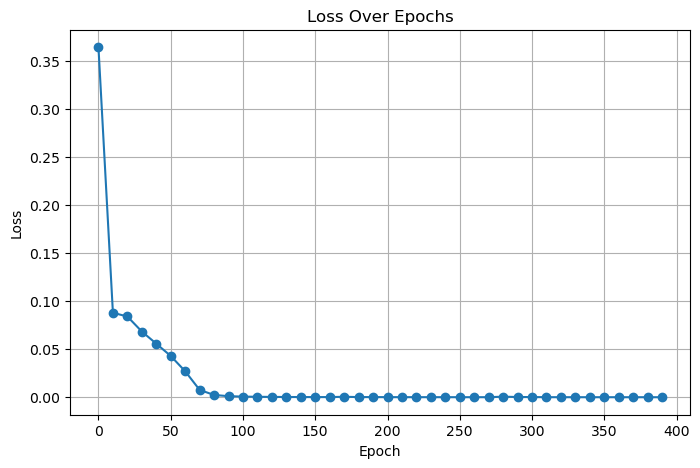

In [169]:
# Training and Evaluation Loop 

epochs = 400 
losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(train_data, train_lengths)
    loss = loss_fn(y_pred, train_sources)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:  # Store every tenth epoch
            loss = loss.detach().numpy()
            losses.append((epoch, loss))

    model.eval()
    with torch.no_grad():
        y_pred_test = model(test_data, test_lengths)
        test_loss = loss_fn(y_pred_test, test_sources)
    
    print(f"Epoch:{epoch +1}")
    print(f"Train Loss:{loss}")
    print(f"Test Loss:{test_loss}")


epochs, loss_values = zip(*losses)  # Unpacking the list of tuples
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_values, marker='o', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.grid()
plt.savefig('losses_64hl_4l_0do_mse.png')



In [33]:
### MODEL RESULTS 
predictions = model(train_data, train_lengths)
predictions = predictions.detach().numpy()
test_predictions = model(test_data, test_lengths)
test_predictions = test_predictions.detach().numpy()

In [34]:
len(predictions), len(train_sources), len(test_predictions), len(test_sources)

(25, 25, 1000, 1000)

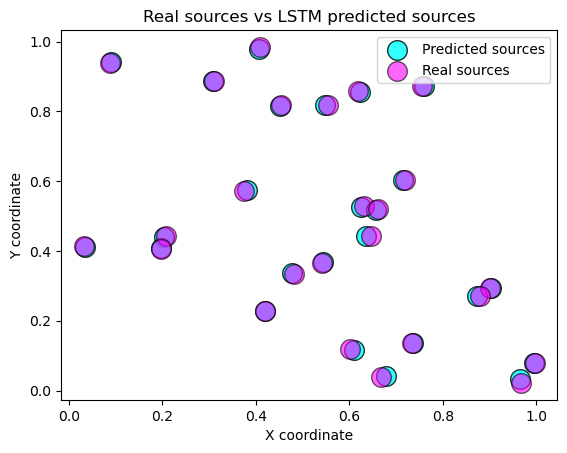

In [15]:
### PLOTTING TRAINING DATA 
plt.scatter(predictions[:,2], predictions[:,1], c='cyan', s = 200, label='Predicted sources', alpha = 0.8, edgecolors='black')
plt.scatter(train_sources[:,2], train_sources[:,1], c='magenta', s=200, label='Real sources', alpha=0.6, edgecolors='black')
plt.title("Real sources vs LSTM predicted sources")
plt.ylabel("Y coordinate")
plt.xlabel("X coordinate")
plt.legend()

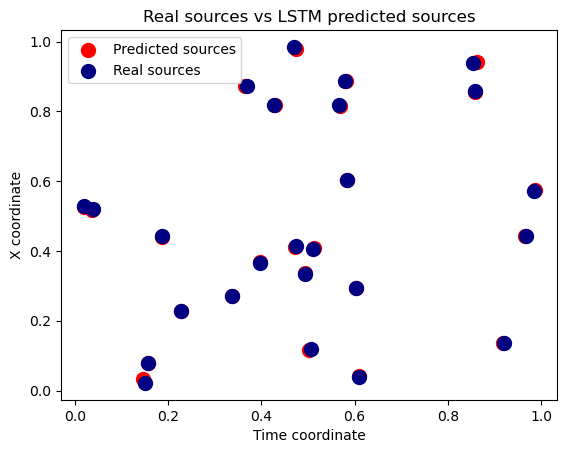

In [244]:
plt.scatter(predictions[:,0], predictions[:,1], c='red', s=100, label='Predicted sources')
plt.scatter(train_sources[:,0], train_sources[:,1], c='navy', s=100, label='Real sources')
plt.title("Real sources vs LSTM predicted sources")
plt.ylabel("X coordinate")
plt.xlabel("Time coordinate")
plt.legend()

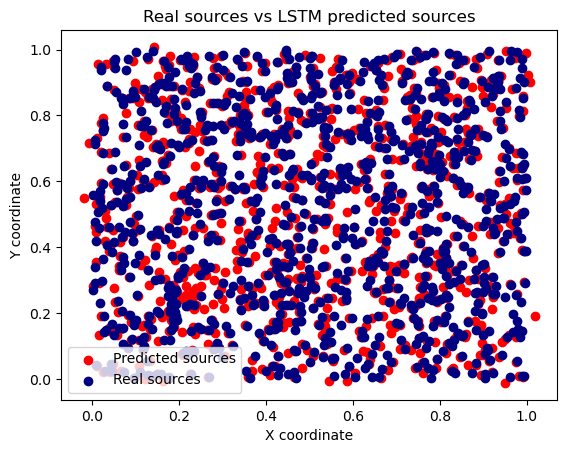

In [224]:
#### PLOTTING TEST DATA 
plt.scatter(test_predictions[:,2], test_predictions[:,1], c='red', label='Predicted sources')
plt.scatter(test_sources[:,2], test_sources[:,1], c='navy', label='Real sources')
plt.title("Real sources vs LSTM predicted sources")
plt.ylabel("Y coordinate")
plt.xlabel("X coordinate")
plt.legend()

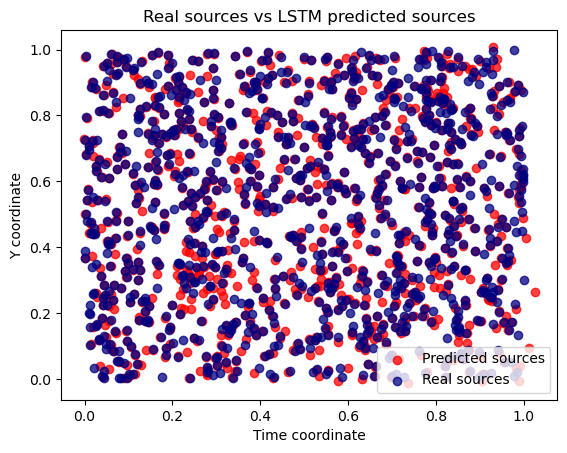

In [234]:
plt.scatter(test_predictions[:,0], test_predictions[:,1], c='red', label='Predicted sources', alpha = 0.75)
plt.scatter(test_sources[:,0], test_sources[:,1], c='navy', label='Real sources', alpha=0.75)
plt.title("Real sources vs LSTM predicted sources")
plt.ylabel("Y coordinate")
plt.xlabel("Time coordinate")
plt.legend()

In [10]:
#### L1 TRAINING LOSS
pred = model(train_data, train_lengths)
loss_fn2 = nn.L1Loss()
lossxyt = loss_fn2(pred, train_sources)
lossyt = loss_fn2(pred[:,1:2], train_sources[:,1:2])
lossxy = loss_fn2(pred[:,:1], train_sources[:,:1])
print(lossxyt, lossxy, lossyt)

tensor(0.0046, grad_fn=<MeanBackward0>) tensor(0.0030, grad_fn=<MeanBackward0>) tensor(0.0030, grad_fn=<MeanBackward0>)


In [82]:
#### L1 TESTING LOSS
pred = model(test_data, test_lengths)
lossxyt = loss_fn2(pred, test_sources)
lossyt = loss_fn2(pred[:,1:2], test_sources[:,1:2])
lossxy = loss_fn2(pred[:,:1], test_sources[:,:1])
print(lossxyt) 
print(lossxy) 
print(lossyt)

tensor(0.0055, grad_fn=<MeanBackward0>)
tensor(0.0050, grad_fn=<MeanBackward0>)
tensor(0.0050, grad_fn=<MeanBackward0>)


In [178]:
print(pred)

tensor([[5.7428e-01, 6.0957e-01, 4.9310e-01],
        [9.5348e-01, 1.7595e-01, 3.9116e-01],
        [6.4158e-01, 1.7012e-01, 5.5332e-01],
        [1.8144e-01, 2.9673e-01, 7.9816e-01],
        [7.6795e-01, 3.3475e-01, 4.2061e-01],
        [5.1334e-01, 2.9651e-01, 1.3111e-01],
        [2.4356e-01, 3.5667e-01, 2.4505e-01],
        [4.5214e-01, 6.3199e-01, 4.3058e-01],
        [6.2017e-01, 4.0452e-01, 9.6353e-01],
        [3.9437e-01, 9.9530e-01, 9.7813e-01],
        [1.8276e-01, 7.5189e-01, 4.3285e-01],
        [8.3681e-01, 9.4726e-01, 8.3867e-01],
        [6.0393e-01, 3.1430e-01, 2.3857e-01],
        [9.5092e-01, 5.9416e-01, 6.9591e-01],
        [2.4543e-01, 7.7792e-01, 8.7653e-01],
        [5.4424e-01, 1.2455e-01, 6.3325e-01],
        [3.9547e-01, 8.0333e-01, 6.9567e-01],
        [3.2406e-01, 7.6135e-01, 8.6623e-04],
        [3.9947e-01, 3.2436e-01, 6.0641e-01],
        [9.2135e-01, 5.2018e-01, 2.1255e-01],
        [4.9620e-01, 8.7272e-01, 9.8511e-01],
        [4.1851e-01, 9.3621e-01, 5

In [179]:
### SAVING THE SUPER AWESOME MODEL
# torch.save(model.state_dict(), '/home/cgillesp/Downloads/LSTM/sourceLSTM0.0.pth')

In [180]:
# torch.save(model.state_dict(), '/home/cgillesp/Downloads/LSTM/sourceLSTM0.1.pth')

In [ ]:
#torch.save(model.state_dict(), '/home/cgillesp/Downloads/LSTM/model parameters/sourceLSTM1.075.pth')